# Predictor–corrector path following & inverse mapping (pounce#84 family)

This notebook tours the path-following toolkit built on POUNCE's
post-solve KKT sensitivity (companion to notebook 13, which covers the
held-factor Jacobian itself). The pieces:

- **`sensitivity_at`** (#87) — exact `∂x*/∂θ` at a *supplied* primal-dual
  point, by re-factoring the KKT there.
- **single-problem wrappers** (#88) — `solve_with_jacobian`,
  `sensitivity`, `jvp_from_state`, `vjp_from_state`, un-batched.
- **`active_set_margin`** (#89) — distance to an active-set change; the
  "predictor about to become invalid" monitor.
- **`PathFollower`** (#90) — predict (sensitivity) → monitor (no solve) →
  correct (warm-μ re-solve), with a pseudo-arclength mode for folds.
- **`inverse_map_rhs`** (#91) — the inverse/uncertainty-mapping ODE RHS
  for integration with diffrax / scipy.

The common engine underneath is one symmetric-indefinite KKT factor,
reused across steps via `kkt_solve_many` — no NLP re-solve on a predict
step.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pounce.jax import JaxProblem, PathFollower, inverse_map_rhs

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

## A parametric NLP

A tiny projection: `min_x ||x - θ||²  s.t.  x0 + x1 = 1`, with box
bounds. The parameter `θ` is the point being projected onto the line.
The solution `x*(θ)` and its sensitivity `∂x*/∂θ` are what we trace.

In [2]:
def f(x, p):
    return jnp.sum((x - p) ** 2)

def g(x, p):
    return jnp.stack([x[0] + x[1] - 1.0])

jp = JaxProblem(
    f=f, g=g, n=2, m=1, p_example=jnp.zeros(2),
    lb=jnp.full(2, -5.0), ub=jnp.full(2, 5.0),
    cl=jnp.zeros(1), cu=jnp.zeros(1),
    options={"tol": 1e-9, "print_level": 0, "sb": "yes"},
)

## 1. Post-solve sensitivity at a point (#87, #88)

`solve_with_jacobian` returns the solution, its duals, and the full
primal Jacobian `J = ∂x*/∂θ` from the held factor — un-batched. The same
`J` can be recomputed at any *supplied* KKT point with `sensitivity_at`
(it re-factors the KKT there, no re-solve), and directional products come
from `jvp_from_state` / `vjp_from_state`.

In [3]:
theta = jnp.array([0.3, 0.7])
x_star, (lam, zL, zU), J = jp.solve_with_jacobian(theta, jnp.zeros(2))
print("x*  =", np.asarray(x_star))
print("J   =", np.asarray(J).tolist())

# Exact sensitivity at the supplied (x*, duals, θ) — matches J.
J_at = jp.sensitivity_at(x_star, theta, (lam, zL, zU))
print("sensitivity_at == J :", bool(np.allclose(J, J_at, atol=1e-8)))

# Directional: J @ dθ from the held factor (one back-solve, no re-solve).
with jp.anchor(theta, jnp.zeros(2)) as state:
    dx = jp.jvp_from_state(state, jnp.array([0.1, -0.05]))
print("J @ dθ =", np.asarray(dx))

x*  = [0.3 0.7]
J   = [[0.49999999999811673, -0.4999999999981167], [-0.4999999999981167, 0.4999999999981167]]


sensitivity_at == J : True


J @ dθ = [ 0.075 -0.075]


## 2. The active-set monitor (#89)

The sensitivity is a derivative on a *fixed* active set. `active_set_margin`
reports how close we are to a change: the smallest active multiplier
(about to leave the set) or inactive slack (about to enter). A small
margin means the predictor is about to become invalid. Here the bounds
are slack and only the equality is active, so the margin is the distance
of `x` to its nearest bound.

In [4]:
with jp.anchor(theta, jnp.zeros(2)) as state:
    m = jp.active_set_margin(state)
print({k: float(np.asarray(v)[0]) for k, v in m.items()})

{'margin': 4.30000000000075, 'min_mult': inf, 'min_slack': 4.30000000000075}


## 3. Predictor–corrector path following (#90)

`PathFollower.follow` traces `x*(θ(s))` along a prescribed path. Each
step **predicts** with the held-factor sensitivity, **monitors** the KKT
residual + active-set margin *without solving*, and only **corrects**
(a warm-μ re-solve that re-anchors the factor) when the monitor trips.

For this linear-response NLP the predictor is exact, so the whole loop is
traced with **zero correctors** — one anchor solve instead of one cold
solve per step.

In [5]:
def circle(s):
    a = 2.0 * jnp.pi * s
    return jnp.array([0.5 + 0.4 * jnp.cos(a), 0.4 * jnp.sin(a)])

pf = PathFollower(jp, monitor_tol=1e-6, ds0=0.05)
tr = pf.follow(circle, (0.0, 1.0), jnp.zeros(2))
print(f"steps={tr.n_steps}  correctors={tr.n_correctors}  accepts={tr.n_accepts}")
print(f"engine solves = 1 + {tr.n_correctors} = {1 + tr.n_correctors}   "
      f"(naive: {tr.n_steps + 1})")
print(f"closed loop |x(1) - x(0)| = {np.max(np.abs(tr.x[0] - tr.x[-1])):.2e}")

steps=7  correctors=0  accepts=7
engine solves = 1 + 0 = 1   (naive: 8)
closed loop |x(1) - x(0)| = 1.53e-16


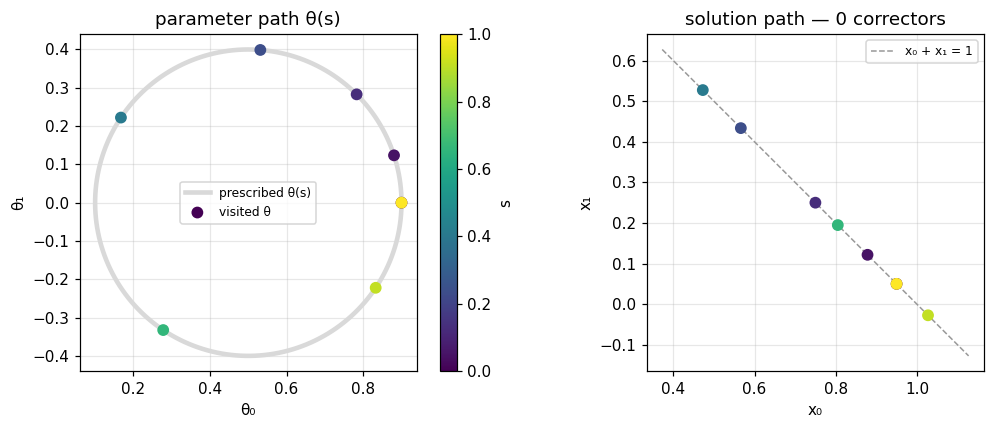

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Parameter space: the prescribed loop, and the θ values actually visited.
ss = np.linspace(0, 1, 400)
loop = np.array([np.asarray(circle(s)) for s in ss])
ax[0].plot(loop[:, 0], loop[:, 1], "-", color="0.85", lw=3, label="prescribed θ(s)")
sc = ax[0].scatter(tr.theta[:, 0], tr.theta[:, 1], c=tr.s, cmap="viridis",
                   s=45, zorder=3, label="visited θ")
ax[0].set(xlabel="θ₀", ylabel="θ₁", title="parameter path θ(s)")
ax[0].set_aspect("equal"); ax[0].legend(fontsize=8, loc="center")
fig.colorbar(sc, ax=ax[0], label="s")

# Solution space: x*(θ(s)) rides the equality constraint.
xs = np.linspace(tr.x[:, 0].min() - 0.1, tr.x[:, 0].max() + 0.1, 10)
ax[1].plot(xs, 1 - xs, "--", color="0.6", lw=1, label="x₀ + x₁ = 1")
ax[1].scatter(tr.x[:, 0], tr.x[:, 1], c=tr.s, cmap="viridis", s=45, zorder=3)
ax[1].set(xlabel="x₀", ylabel="x₁", title=f"solution path — {tr.n_correctors} correctors")
ax[1].set_aspect("equal"); ax[1].legend(fontsize=8)

plt.show()

Left, the prescribed loop in parameter space with the points the follower
actually stopped at (colour = path parameter `s`); right, the
corresponding solution path, which rides the equality constraint
`x₀ + x₁ = 1` exactly. Every one of those solution points came from a
back-solve on the anchor's factor — the trace never re-solved the NLP.

### Curvature: the monitor trades accuracy for solves

With a nonlinear objective the linear predictor drifts, so the monitor
fires correctors. Loosening `monitor_tol` accepts more predictor steps
between (warm) re-solves — fewer solves at a controlled error, exactly
the predictor–corrector lever.

In [7]:
def f_nl(x, p):
    return jnp.sum((x - p) ** 2) + 0.02 * jnp.sum(x ** 4)

jp_nl = JaxProblem(
    f=f_nl, g=g, n=2, m=1, p_example=jnp.zeros(2),
    lb=jnp.full(2, -5.0), ub=jnp.full(2, 5.0),
    cl=jnp.zeros(1), cu=jnp.zeros(1),
    options={"tol": 1e-9, "print_level": 0, "sb": "yes"},
)
for tol in (1e-3, 5e-3):
    t = PathFollower(jp_nl, monitor_tol=tol, ds0=0.05, ds_max=0.1).follow(
        circle, (0.0, 1.0), jnp.zeros(2))
    err = max(
        float(np.max(np.abs(t.x[k] - np.asarray(
            jp_nl.solve_with_jacobian(jnp.asarray(t.theta[k]), jnp.zeros(2))[0]))))
        for k in range(len(t.s)))
    print(f"tol={tol:5.0e}: solves={1 + t.n_correctors:2d} (naive {t.n_steps + 1}), "
          f"accepts={t.n_accepts}, max err={err:.1e}")

tol=1e-03: solves= 9 (naive 12), accepts=3, max err=2.3e-04


tol=5e-03: solves= 5 (naive 12), accepts=7, max err=8.7e-04


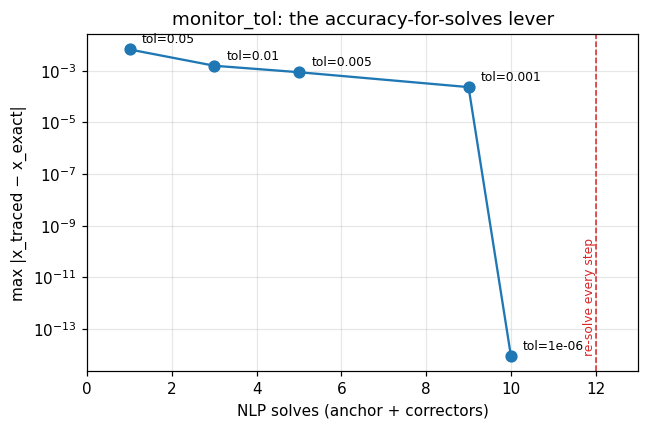

In [8]:
tols = [1e-6, 1e-3, 5e-3, 1e-2, 5e-2]
solves, errs = [], []
for tol in tols:
    t = PathFollower(jp_nl, monitor_tol=tol, ds0=0.05, ds_max=0.1).follow(
        circle, (0.0, 1.0), jnp.zeros(2))
    err = max(
        float(np.max(np.abs(t.x[k] - np.asarray(
            jp_nl.solve_with_jacobian(jnp.asarray(t.theta[k]), jnp.zeros(2))[0]))))
        for k in range(len(t.s)))
    solves.append(1 + t.n_correctors)
    errs.append(max(err, 1e-16))
naive = t.n_steps + 1

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(solves, errs, "o-", ms=7)
for tol, s, e in zip(tols, solves, errs):
    ax.annotate(f"tol={tol:g}", (s, e), textcoords="offset points",
                xytext=(8, 4), fontsize=8)
ax.axvline(naive, color="C3", ls="--", lw=1)
ax.annotate("re-solve every step", (naive, errs[0]), color="C3", fontsize=8,
            rotation=90, va="bottom", ha="right")
ax.set(xscale="linear", yscale="log", xlabel="NLP solves (anchor + correctors)",
       ylabel="max |x_traced − x_exact|",
       title="monitor_tol: the accuracy-for-solves lever")
ax.set_xlim(0, naive + 1)
plt.show()

The lever, drawn. Each point is one `monitor_tol`: down-and-right is more
solves for more accuracy, up-and-left is fewer solves for less. The
dashed line is what a naive re-solve-every-step loop would cost. Note the
knee — around `tol=1e-3` the path error is still ~1e-4 at nearly half the
solves, while tightening past that buys machine precision for the last
few solves.

## 4. Tracing past a fold (pseudo-arclength)

When the path *folds* — `∂x*/∂θ` singular — parameter continuation
stalls. `trace_arclength` parametrises the solution curve by arclength
and Newton-corrects the augmented KKT, passing through turning points.
The stationarity of `f = x⁴/4 − x²/2 − θx` is `θ = x³ − x`, which folds
at `x = ±1/√3` (`θ = ∓0.385`).

In [9]:
def f_cubic(x, p):
    th = p[0]
    return x[0] ** 4 / 4.0 - x[0] ** 2 / 2.0 - th * x[0]

jp_c = JaxProblem(f=f_cubic, g=None, n=1, m=0, p_example=jnp.zeros(1),
                  options={"tol": 1e-10, "print_level": 0, "sb": "yes"})
trc = PathFollower(jp_c).trace_arclength(jnp.array([-1.3]), -0.4,
                                         ds=0.05, n_steps=120)
print("turning points (θ):", [round(t, 4) for t in trc.turning_points])
print("x range:", float(trc.x[:, 0].min()), "→", float(trc.x[:, 0].max()))

turning points (θ): [0.3843, -0.3805]
x range: -1.1597048527648892 → 1.6534582542846283


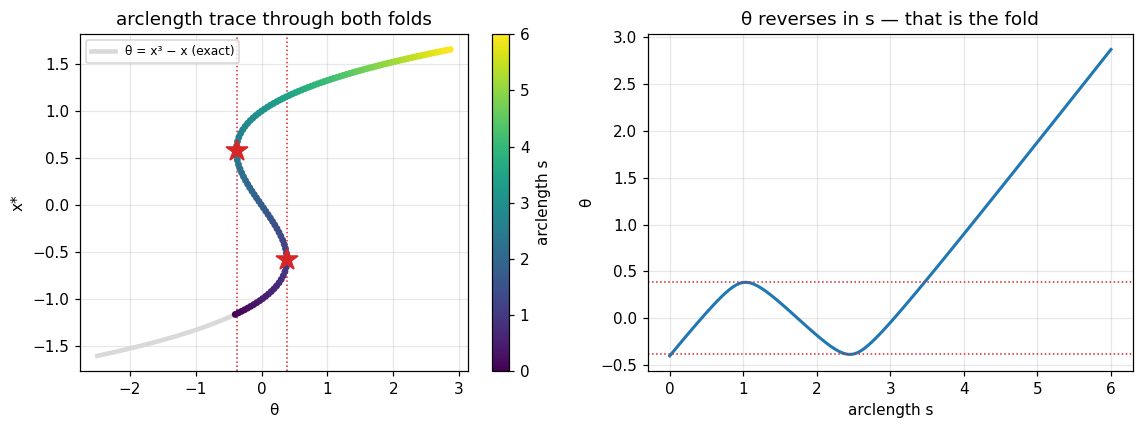

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4))

# The stationary set θ = x³ − x is the exact curve being traced.
xg = np.linspace(-1.6, 1.6, 400)
ax[0].plot(xg ** 3 - xg, xg, "-", color="0.85", lw=3, label="θ = x³ − x (exact)")
sc = ax[0].scatter(trc.theta, trc.x[:, 0], c=trc.s, cmap="viridis", s=12, zorder=3)
for tp in trc.turning_points:
    ax[0].axvline(tp, color="C3", ls=":", lw=1)
    ax[0].plot([tp], [np.sign(-tp) / np.sqrt(3)], "*", color="C3", ms=15, zorder=4)
ax[0].set(xlabel="θ", ylabel="x*", title="arclength trace through both folds")
ax[0].legend(fontsize=8, loc="upper left")
fig.colorbar(sc, ax=ax[0], label="arclength s")

# Why parameter continuation stalls: θ is not monotone in s.
ax[1].plot(trc.s, trc.theta, lw=2)
for tp in trc.turning_points:
    ax[1].axhline(tp, color="C3", ls=":", lw=1)
ax[1].set(xlabel="arclength s", ylabel="θ",
          title="θ reverses in s — that is the fold")

plt.show()

The S-curve is the whole story. Colour is arclength, so you can read the
trace walking up the lower branch, **through** the first fold (star),
back across the middle branch, through the second fold, and out along the
upper branch. The right panel is the same run plotted against arclength:
`θ` rises, reverses, and rises again. Any method that treats `θ` as the
independent variable stalls at those reversals — parametrising by
arclength is exactly what steps past them.

## 5. Inverse / uncertainty mapping as an ODE (#91)

The Alves–Kitchin–Lima inverse map sends a closed boundary in *output*
space back to *input* space by integrating

$$\frac{d\theta}{ds} = \Big(\frac{\partial y}{\partial\theta}\Big)^{-1}\frac{dy}{ds},$$

where the output `y = output(x*(θ), θ)` is an output of the embedded
optimizer. `inverse_map_rhs` builds this RHS from the POUNCE sensitivity;
hand it to diffrax or scipy. Note it is a **linear solve against** the
sensitivity, not a `J @ v`. Here `output = x*`, so for
`f = (x−θ)² + 0.05x⁴` the map is explicit (`θ = y + 0.1y³`), giving an
analytic check.

In [11]:
import diffrax

def f_inv(x, p):
    return (x[0] - p[0]) ** 2 + 0.05 * x[0] ** 4

jp_inv = JaxProblem(f=f_inv, g=None, n=1, m=0, p_example=jnp.zeros(1),
                    options={"tol": 1e-11, "print_level": 0, "sb": "yes"})

y_of_s  = lambda s: jnp.array([0.5 + 0.3 * jnp.sin(2 * jnp.pi * s)])
dy_ds   = lambda s: jnp.array([0.3 * 2 * jnp.pi * jnp.cos(2 * jnp.pi * s)])
rhs = inverse_map_rhs(jp_inv, dy_ds)   # f(s, θ) -> dθ/ds; jit/diffrax-ready

# Integrate the closed output loop with diffrax: adaptive Dopri5 + a PID
# controller and dense output on a uniform grid. The POUNCE solve inside
# `rhs` rides a jax.pure_callback, so it composes under the integrator
# untouched — no hand-rolled stepper. (Standalone script with a 2-D
# coupled problem and a round-trip check: examples/inverse_map_diffrax.py.)
y0 = float(y_of_s(0.0)[0])
theta0 = jnp.array([y0 + 0.1 * y0 ** 3])   # θ0 with x*(θ0) = y(0)

term = diffrax.ODETerm(lambda s, theta, args: rhs(s, theta))
S = jnp.linspace(0.0, 1.0, 201)
sol = diffrax.diffeqsolve(
    term, diffrax.Dopri5(), t0=0.0, t1=1.0, dt0=0.01, y0=theta0,
    stepsize_controller=diffrax.PIDController(rtol=1e-9, atol=1e-11),
    saveat=diffrax.SaveAt(ts=S), max_steps=100_000,
)
TH = np.asarray(sol.ys[:, 0])

ys = 0.5 + 0.3 * np.sin(2 * np.pi * np.asarray(S))
print("diffrax steps     :", int(sol.stats["num_steps"]), "(adaptive)")
print("closed input loop :", abs(TH[-1] - TH[0]))
print("vs analytic θ     :", float(np.max(np.abs(TH - (ys + 0.1 * ys ** 3)))))

diffrax steps     : 43 (adaptive)
closed input loop : 7.31474436577173e-10
vs analytic θ     : 7.200954146857619e-08


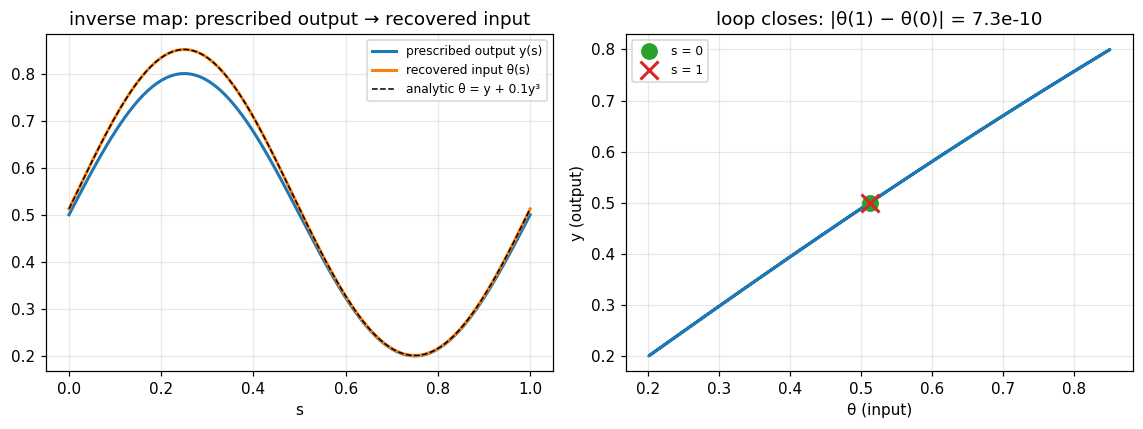

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4))

ax[0].plot(S, ys, lw=2, label="prescribed output y(s)")
ax[0].plot(S, TH, lw=2, label="recovered input θ(s)")
ax[0].plot(S, ys + 0.1 * ys ** 3, "k--", lw=1, label="analytic θ = y + 0.1y³")
ax[0].set(xlabel="s", title="inverse map: prescribed output → recovered input")
ax[0].legend(fontsize=8)

ax[1].plot(TH, ys, lw=2)
ax[1].plot(TH[0], ys[0], "o", ms=10, color="C2", label="s = 0")
ax[1].plot(TH[-1], ys[-1], "x", ms=12, mew=2, color="C3", label="s = 1")
ax[1].set(xlabel="θ (input)", ylabel="y (output)",
          title=f"loop closes: |θ(1) − θ(0)| = {abs(TH[-1] - TH[0]):.1e}")
ax[1].legend(fontsize=8)

plt.show()

Left: the prescribed output loop and the input path recovered by
integrating the sensitivity ODE, sitting on top of the analytic
`θ = y + 0.1y³`. Right: the same trace in the (input, output) plane — a
closed loop in output space returns a closed loop in input space, and the
start and end markers coincide to ~1e-9. That round-trip is the cheapest
correctness check available on an inverse map, since no reference
solution is needed.

## When to use which

- **`PathFollower.follow`** — robust default: the optimizer's active set
  may change along the path; the monitor + warm-μ corrector handle it.
- **`PathFollower.trace_arclength`** — the path folds (singular
  `∂x*/∂θ`), scalar-parameter equality/unconstrained branch.
- **`inverse_map_rhs` + an ODE integrator** — the map is smooth, the
  active set is fixed, and you want adaptive stepping / dense output from
  diffrax or scipy. Switch to `PathFollower` if it folds or the active
  set changes.

All three run on the same held KKT factor; a predict step is one
`kkt_solve_many` back-solve, never an NLP re-solve.